In [2]:
import sqlite3 #connects to sqlite3 and to create new database 
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
conn=sqlite3.connect('sales_data.db') #database created
cursor=conn.cursor()

In [6]:
#create table
cursor.execute('''
create table if not exists sales(
id integer primary key,
product text,
quantity integer,
price real
)
''')

In [20]:
#insert data into table
sample_data=[
    ('apple',10,2.5),
    ('banana',5,1.6),
    ('orange',8,1.8),
    ('apple',6,2.5),
    ('banana',9,1.0),
    ('orange',7,1.8),
    ('grapes',12,3.8),
    ('berrys',5,2.85,),
    ('leamon',9,11.9),
     ]    
cursor.executemany("insert into sales(product,quantity,price) values(?,?,?)", sample_data)
conn.commit() #store the data permanently to the database sales_data.db ie conn(variable) is user to create the database

In [24]:
df=pd.read_sql_query("select * from sales",conn)
print(df)

   id product  quantity  price
0   1   apple        10   2.50
1   2  banana         5   1.60
2   3  orange         8   1.80
3   4   apple         6   2.50
4   5  banana         9   1.00
5   6  orange         7   1.80
6   7  grapes        12   3.80
7   8  berrys         5   2.85
8   9  leamon         9  11.90


In [53]:
query = """select
            product,
            sum(quantity) as total_quantity,
            sum(quantity*price) as revenue
        from sales
        group by product"""

In [55]:
df=pd.read_sql_query(query,conn)
print(df)

  product  total_quantity  revenue
0   apple              16    40.00
1  banana              14    17.00
2  berrys               5    14.25
3  grapes              12    45.60
4  leamon               9   107.10
5  orange              15    27.00


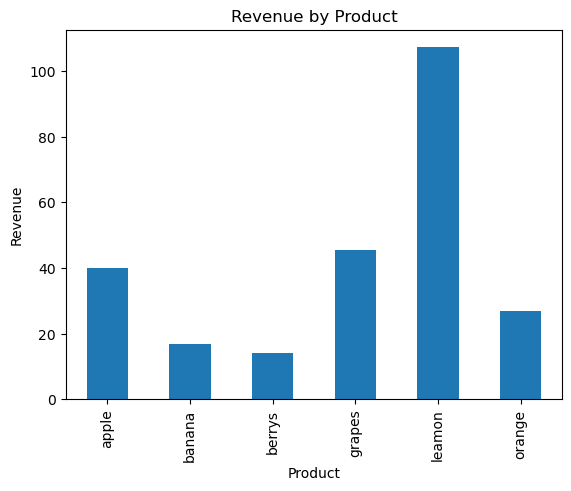

In [59]:
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title('Revenue by Product')
plt.ylabel('Revenue')
plt.xlabel('Product')
plt.show()